In [1]:
#General packages
from IPython.display import clear_output #import of a single funtcion
import sys #system related packages
import os #better path and file handling
import pickle #saving and loading objects

#Tables, numbers etc
import pandas as pd #tables
import numpy as np #arrays
import scipy #sciency functions
from sklearn import mixture #For gaussian mixture model

#Plotting packages
import matplotlib.pyplot as plt #Main plotting
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import seaborn as sbn #nicer plots

#RNA-seq analysis
import scanpy as sc #Main package for scRNA-seq analysis
import scanpy.external as sce #some more functions for scanpy
import bbknn #batch correction

#Import some custom helper functions for plotting
path_skin_scripts = '/mnt/p/users/Karl/Python/Projects'
sys.path.append(path_skin_scripts)
from Skin_scripts import *

In [2]:
path = convert_path(r'P:\IMPORTANT-Backup-Sequencing-Projects\2024_Hao_HSCA_Integration_datasets\dataset\iHSCA_20251110')
path

'/mnt/p/IMPORTANT-Backup-Sequencing-Projects/2024_Hao_HSCA_Integration_datasets/dataset/iHSCA_20251110'

In [3]:
adata_pca = sc.read_h5ad(os.path.join(path, 'Keratinocyte_Hao_clustering_hvg.h5ad'))
adata_annotation = sc.read_h5ad(os.path.join(path, 'Keratinocyte_Karl_IntegratedAnnotation_2_20250531.h5ad'))

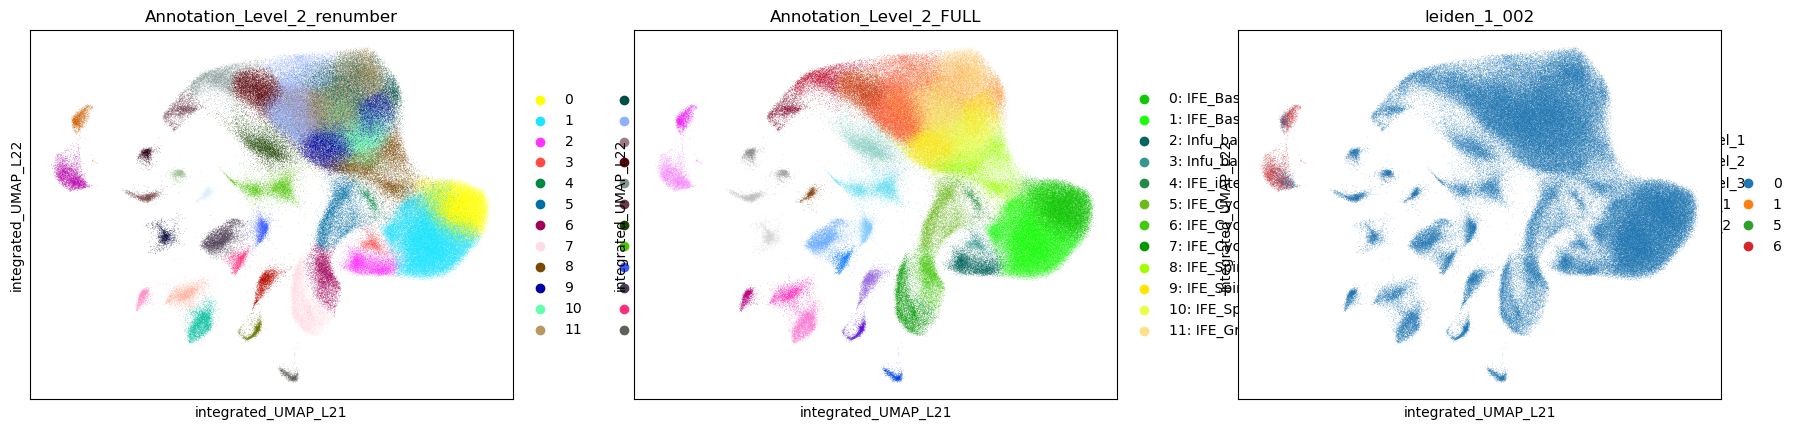

In [4]:
sc.pl.embedding(adata_annotation, basis = 'integrated_UMAP_L2', color = ['Annotation_Level_2_renumber', 'Annotation_Level_2_FULL', 'leiden_1_002'])

In [17]:
pcs = adata_pca[adata_annotation.obs_names].obsm['PCA_use'].copy()

In [18]:
import geosketch as gs

In [74]:
subset = 50000
sketch_index = gs.gs(pcs, subset, replace = False)
sketch_index

[np.int64(16),
 np.int64(20),
 np.int64(21),
 np.int64(22),
 np.int64(30),
 np.int64(35),
 np.int64(36),
 np.int64(43),
 np.int64(46),
 np.int64(63),
 np.int64(70),
 np.int64(72),
 np.int64(83),
 np.int64(85),
 np.int64(87),
 np.int64(98),
 np.int64(100),
 np.int64(103),
 np.int64(110),
 np.int64(122),
 np.int64(125),
 np.int64(127),
 np.int64(132),
 np.int64(142),
 np.int64(144),
 np.int64(149),
 np.int64(153),
 np.int64(160),
 np.int64(162),
 np.int64(165),
 np.int64(179),
 np.int64(182),
 np.int64(183),
 np.int64(188),
 np.int64(192),
 np.int64(194),
 np.int64(197),
 np.int64(199),
 np.int64(200),
 np.int64(204),
 np.int64(212),
 np.int64(218),
 np.int64(221),
 np.int64(232),
 np.int64(233),
 np.int64(235),
 np.int64(238),
 np.int64(242),
 np.int64(243),
 np.int64(257),
 np.int64(261),
 np.int64(271),
 np.int64(272),
 np.int64(275),
 np.int64(277),
 np.int64(278),
 np.int64(279),
 np.int64(280),
 np.int64(286),
 np.int64(288),
 np.int64(303),
 np.int64(306),
 np.int64(309),
 np.int6

In [75]:
mask = np.zeros(len(adata_annotation))
mask[sketch_index] = 1
sum(mask)

np.float64(50000.0)

In [76]:
adata_annotation.obs['selection'] = mask
adata_annotation.obs['selection'] = adata_annotation.obs['selection'].map({0:'not', 1:'selected'})

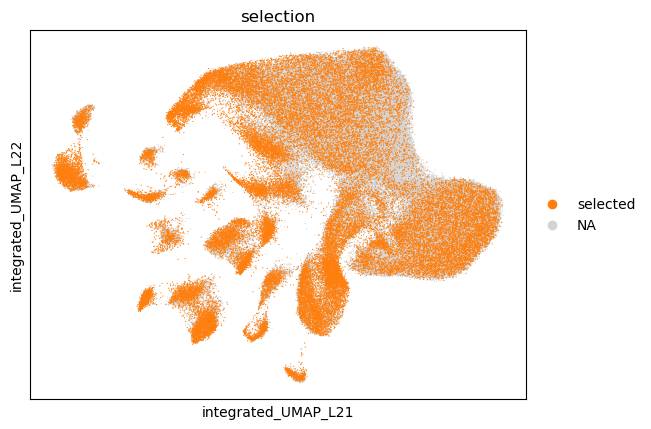

In [79]:
sc.pl.embedding(adata_annotation, basis = 'integrated_UMAP_L2', color = ['selection'], groups = ['selected'], s = 3)

In [73]:
{cl: adata_annotation.uns['Annotation_Level_2_FULL_colors'][ix] for ix, cl in enumerate(adata_annotation.obs['Annotation_Level_2_FULL'].cat.categories)}

{'0: IFE_Basal_1': '#0fc702ff',
 '1: IFE_Basal_2': '#1cfc0dff',
 '2: Infu_basal_1': '#01665eff',
 '3: Infu_basal_2': '#35978fff',
 '4: IFE_interferon': '#238b45ff',
 '5: IFE_Cycling_S': '#6bba18ff',
 '6: IFE_Cycling_G2M_1': '#42c908ff',
 '7: IFE_Cycling_G2M_2': '#009900ff',
 '8: IFE_Spinous_1': '#a2ff00ff',
 '9: IFE_Spinous_2': '#ffe600ff',
 '10: IFE_Spinous_2.1': '#eaff4aff',
 '11: IFE_Granular_1': '#fee08bff',
 '12: IFE_Granular_1.1': '#fc9a3aff',
 '13: IFE_Granular_2': '#fc4e2aff',
 '14: IFE_Granular_2.1': '#fd8d3cff',
 '15: IFE_Granular_3': '#cc3d10ff',
 '16: IFE_terminal_1': '#bd0026ff',
 '17: IFE_terminal_2': '#800026ff',
 '18: Infu_diff': '#80cdc1ff',
 '19: uHF': '#55ddf2ff',
 '20: HF_1': '#7acbfaff',
 '21: HF_2': '#65acfcff',
 '22: HF_3': '#0d7dfcff',
 '23: HF_Anagen': '#0246e3ff',
 '24: SG_1': '#9667e0ff',
 '25: SG_2': '#5f15d6ff',
 '26: Gland_Channel_1': '#fa70d1ff',
 '27: Gland_Channel_2': '#fc21bbff',
 '28: Gland_Channel_3': '#ba0283ff',
 '29: Gland_Sweat_1': '#f682faff',
 

In [43]:
out_path = '/mnt/p/users/Karl/Stereoscope/Data/'
adata_annotation[adata_annotation.obs['selection']=='selected'].write_h5ad(os.path.join(out_path, f'iHSCA_KC_geosketch_subsample_{subset}.h5ad'))

In [81]:
tmp = adata_annotation[adata_annotation.obs['selection']=='selected'][:, adata_annotation.var['highly_variable']].copy()

In [82]:
df = pd.DataFrame(np.astype(tmp.layers['raw_counts'].toarray(), np.int32), index=tmp.obs_names, columns=tmp.var_names)

In [62]:
iHSCA_KC_HVG = df.columns

In [ ]:
%store iHSCA_KC_HVG

Retrieve a list of shared genes between KC HVGs and stereoscope data, can easily be 

In [66]:
%store -r stereoscope_shared_genes

In [84]:
df[stereoscope_shared_genes].to_csv(os.path.join(out_path, f'iHSCA_KC_geosketch_subsample_{subset}_HVG_RAW.tsv'), sep='\t')
tmp.obs['Annotation_Level_2_FULL'].to_csv(os.path.join(out_path, f'iHSCA_KC_geosketch_subsample_{subset}_clusters.tsv'), sep = '\t')

In [69]:
df[stereoscope_shared_genes]

,A2M,A2ML1,AACS,AADAC,AADACL2,AARD,ABCA1,ABCA12,ABCC4,ABHD12B,...,ZG16B,ZNF217,ZNF296,ZNF331,ZNF367,ZNF503,ZNF703,ZNF711,ZNF750,ZWINT
AACATAGCCTGTTGGACAGG---SS3_HumanSkin_20K,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AACGGACTCGCCAACCTATA---SS3_HumanSkin_20K,0,0,0,0,0,0,0,2,0,0,...,0,109,0,1,0,0,0,0,0,0
AAGAAGATCCCCACCAATTG---SS3_HumanSkin_20K,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAGCCTGTTATACGACACTT---SS3_HumanSkin_20K,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AATCGTCGGAATAGTGATGG---SS3_HumanSkin_20K,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TACTCGCAGCGGCTTC-1---Xu_Chen_Nature_2022,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TACTCGCTCTCAAACG-1---Xu_Chen_Nature_2022,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TATTACCTCATGGTCA-1---Xu_Chen_Nature_2022,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
TCGTAGAAGGCAAAGA-1---Xu_Chen_Nature_2022,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,1,0,0,2


Stored 'iHSCA_KC_HVG' (Index)


# Process all datasets

In [86]:
datasets = ['VascularEndothelialCell_IntegratedAnnotation_2_20250531.h5ad',
 'SchwannCell_IntegratedAnnotation_2_20250531.h5ad',
 'MyeloidCell_IntegratedAnnotation_2_20250531.h5ad',
 'LymphaticEndothelialCell_IntegratedAnnotation_2_20250531.h5ad',
 'MastCell_Supported_IntegratedAnnotation_2_20250531.h5ad',
 'Lymphocyte_IntegratedAnnotation_2_20250531.h5ad',
 'Fibroblast_IntegratedAnnotation_2_20250531.h5ad',
 'LEC_20251124_IntegratedAnnotation_2_20250531.h5ad',
 'Melanocyte_IntegratedAnnotation_2_20251001.h5ad',
 #'Keratinocyte_Hao_clustering_hvg.h5ad',
 #'Keratinocyte_Karl_IntegratedAnnotation_2_20250531.h5ad', #KCs are done in the KC clustering hierarchy notebook
 'MuralCell_IntegratedAnnotation_2_20250531.h5ad',]

for dataset in datasets:
    print(dataset)
    adata = sc.read_h5ad(os.path.join(path, dataset))[:, stereoscope_shared_genes]
    name = dataset.split('_')[0]

    df = pd.DataFrame(np.astype(adata.layers['raw_counts'].toarray(), np.int32), index=adata.obs_names, columns=adata.var_names)
    df.to_csv(os.path.join(out_path, f'iHSCA_{name}_HVG_RAW.tsv'), sep='\t')
    adata.obs['Annotation_Level_2_FULL'].to_csv(os.path.join(out_path, f'iHSCA_{name}_clusters.tsv'), sep = '\t')

VascularEndothelialCell_IntegratedAnnotation_2_20250531.h5ad
SchwannCell_IntegratedAnnotation_2_20250531.h5ad
MyeloidCell_IntegratedAnnotation_2_20250531.h5ad
LymphaticEndothelialCell_IntegratedAnnotation_2_20250531.h5ad
MastCell_Supported_IntegratedAnnotation_2_20250531.h5ad
Lymphocyte_IntegratedAnnotation_2_20250531.h5ad
Fibroblast_IntegratedAnnotation_2_20250531.h5ad
LEC_20251124_IntegratedAnnotation_2_20250531.h5ad
Melanocyte_IntegratedAnnotation_2_20251001.h5ad
MuralCell_IntegratedAnnotation_2_20250531.h5ad
